In [7]:
# If any import below fails, uncomment the line below, run it, then Restart Runtime:
# !pip install -q scikit-learn tensorflow opencv-python-headless

# ============================================================
# 🔧 Environment & Setup Check
# Run this first. It confirms every library works before we
# start building, and tells you if a GPU is available.
# ============================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

import cv2
print("OpenCV version:", cv2.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print(f"\n✅ GPU available: {gpu_devices[0].name} — Project 2 will run faster.")
else:
    print("\nℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.")
    print("   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU")

print("\nAll core libraries imported successfully. You're ready to go! 🚀")

Python version: 3.11.9
NumPy version: 2.4.6
Pandas version: 3.0.5
scikit-learn version: 1.9.0
TensorFlow version: 2.21.0
OpenCV version: 4.10.0

ℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.
   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU

All core libraries imported successfully. You're ready to go! 🚀


In [8]:
import cv2

print(cv2.__version__)
print(cv2.__file__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
c:\Users\NIVEDITA RANI\OneDrive\Desktop\Face_Detection\venv\Lib\site-packages\cv2\__init__.py
True


In [9]:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

face_detector = cv2.CascadeClassifier(cascade_path)

print("Face detector loaded:", not face_detector.empty())

Face detector loaded: True


In [10]:
import os
import urllib.request

FALLBACK_FACE_URL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
FALLBACK_FACE_PATH = "sample_face.jpg"
face_image_path = None

# Option A: upload your own image (works in Google Colab)
try:
    from google.colab import files
    print("📤 Upload an image with one or more faces. Cancel/skip to use a sample image instead.")
    uploaded = files.upload()
    if uploaded:
        face_image_path = list(uploaded.keys())[0]
except ImportError:
    pass  # not running in Colab

# Option B: guaranteed fallback so the demo always works
if not face_image_path:
    if not os.path.exists(FALLBACK_FACE_PATH):
        urllib.request.urlretrieve(FALLBACK_FACE_URL, FALLBACK_FACE_PATH)
    face_image_path = FALLBACK_FACE_PATH
    print(f"ℹ️ Using sample image: {face_image_path} (re-run this cell to upload your own, or use the webcam cell below)")

face_image = cv2.imread(face_image_path)
print("Image loaded:", face_image_path, "| Shape:", face_image.shape if face_image is not None else None)

ℹ️ Using sample image: sample_face.jpg (re-run this cell to upload your own, or use the webcam cell below)
Image loaded: sample_face.jpg | Shape: (512, 512, 3)


In [11]:
if face_image is None:
    print("No image available. Re-run the acquisition cell above.")
else:
    gray_image = cv2.cvtColor(
        face_image,
        cv2.COLOR_BGR2GRAY
    )

    faces = face_detector.detectMultiScale(
        gray_image,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    print("Faces detected:", len(faces))

Faces detected: 1


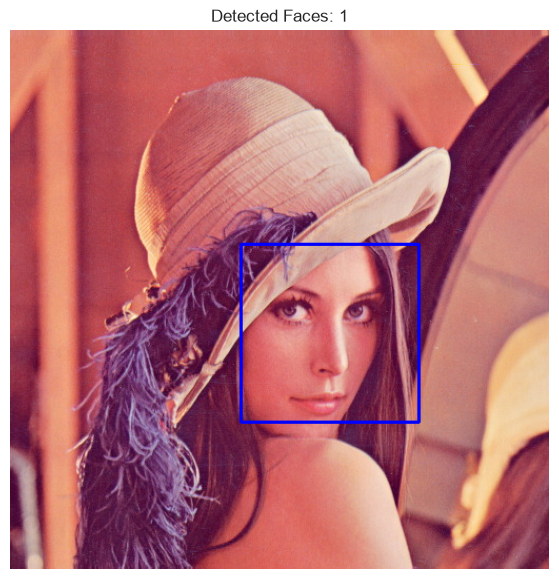

In [12]:
if face_image is not None:
    output_image = face_image.copy()

    for (x, y, w, h) in faces:
        cv2.rectangle(
            output_image,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

    output_rgb = cv2.cvtColor(
        output_image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(10, 7))
    plt.imshow(output_rgb)
    plt.axis("off")
    plt.title(f"Detected Faces: {len(faces)}")
    plt.show()